In [1]:
# # FEATURE ENGINEERING & PCA TUTORIAL
# ## Learning Lab: Iris Dataset
# 
# **Purpose:** Learn all the techniques you'll need for your diabetes homework
# **Dataset:** Iris Flowers (3 species, 4 features)
# **Homework Dataset:** Diabetes (will use same methods!)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Settings for better visuals
plt.style.use('default')
sns.set_palette("Set2")

print("=" * 60)
print("WELCOME TO THE PCA & FEATURE ENGINEERING LAB")
print("Complete this lab first, then apply same steps to diabetes.csv")
print("=" * 60)

WELCOME TO THE PCA & FEATURE ENGINEERING LAB
Complete this lab first, then apply same steps to diabetes.csv


# TASK 1: Data Loading and Exploration (15 points)
## Skills: Load data, check shape, summary stats, missing values

In [2]:
print("\n" + "=" * 60)
print("TASK 1: DATA LOADING AND EXPLORATION")
print("=" * 60)

# Load iris dataset
df = sns.load_dataset('iris')
print("\n✅ Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Column names: {list(df.columns)}")

# Check first few rows
print("\n✅ First 5 rows:")
print(df.head())

# Summary statistics (5 points)
print("\n✅ Summary Statistics:")
print(df.describe())

# Missing values (5 points)
print("\n✅ Missing Values Check:")
print(df.isnull().sum())
print(f"Total missing values: {df.isnull().sum().sum()}")

# Check target variable distribution
print("\n✅ Target Variable Distribution:")
print(df['species'].value_counts())

print("\n💡 HINT for Homework: Use df.describe() and df.isnull().sum() on diabetes.csv")


TASK 1: DATA LOADING AND EXPLORATION

✅ Dataset loaded successfully!
Shape: 150 rows, 5 columns
Column names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

✅ First 5 rows:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

✅ Summary Statistics:
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.00000

# TASK 2: Data Cleaning (15 points)
## Skills: Handle bad values, remove duplicates

In [3]:
print("\n" + "=" * 60)
print("TASK 2: DATA CLEANING")
print("=" * 60)

# Check for duplicates
print(f"Before removing duplicates: {len(df)} rows")
df = df.drop_duplicates()
print(f"After removing duplicates: {len(df)} rows")

# Note: Iris has no zeros to replace, but your diabetes dataset will!
print("\n✅ Special Note for Diabetes Homework:")
print("Diabetes dataset has zeros in columns like Glucose, BMI (0 means missing)")
print("You'll need to replace zeros with median:")
print("""
for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    df[col] = df[col].replace(0, df[col].median())
""")

print("\n💡 HINT: Always check for 0 values in medical datasets - they often mean 'missing'")


TASK 2: DATA CLEANING
Before removing duplicates: 150 rows
After removing duplicates: 149 rows

✅ Special Note for Diabetes Homework:
Diabetes dataset has zeros in columns like Glucose, BMI (0 means missing)
You'll need to replace zeros with median:

for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    df[col] = df[col].replace(0, df[col].median())


💡 HINT: Always check for 0 values in medical datasets - they often mean 'missing'


# TASK 3: Z-Score Standardization (20 points)
## Skills: Separate X/y, apply StandardScaler, verify results

In [4]:
print("\n" + "=" * 60)
print("TASK 3: Z-SCORE STANDARDIZATION")
print("=" * 60)

# Separate features and target
X = df.drop('species', axis=1)  # All numeric columns
y = df['species']  # Target variable

print(f"Features (X) shape: {X.shape}")
print(f"Features names: {list(X.columns)}")
print(f"Target (y) shape: {y.shape}")

# Check original scales
print("\n✅ Before Scaling - Different units/sepal_es:")
print(f"sepal_length: mean={X['sepal_length'].mean():.2f}, std={X['sepal_length'].std():.2f}")
print(f"sepal_width:  mean={X['sepal_width'].mean():.2f}, std={X['sepal_width'].std():.2f}")
print(f"petal_length: mean={X['petal_length'].mean():.2f}, std={X['petal_length'].std():.2f}")
print(f"petal_width:  mean={X['petal_width'].mean():.2f}, std={X['petal_width'].std():.2f}")

# Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easier viewing
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("\n✅ After Scaling - All features now have mean=0, std=1:")
print(f"sepal_length: mean={X_scaled_df['sepal_length'].mean():.2f}, std={X_scaled_df['sepal_length'].std():.2f}")
print(f"sepal_width:  mean={X_scaled_df['sepal_width'].mean():.2f}, std={X_scaled_df['sepal_width'].std():.2f}")
print(f"petal_length: mean={X_scaled_df['petal_length'].mean():.2f}, std={X_scaled_df['petal_length'].std():.2f}")
print(f"petal_width:  mean={X_scaled_df['petal_width'].mean():.2f}, std={X_scaled_df['petal_width'].std():.2f}")

print("\n✅ Advantages of Z-Score Standardization:")
print("1. All features contribute equally to PCA (no bias toward large numbers)")
print("2. Required for PCA to work correctly")
print("3. Makes interpretation easier (all in same units)")
print("4. Improves algorithm performance")

print("\n💡 HINT for Homework: Use StandardScaler() on ALL numeric features except 'Outcome'")


TASK 3: Z-SCORE STANDARDIZATION
Features (X) shape: (149, 4)
Features names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Target (y) shape: (149,)

✅ Before Scaling - Different units/sepal_es:
sepal_length: mean=5.84, std=0.83
sepal_width:  mean=3.06, std=0.44
petal_length: mean=3.75, std=1.77
petal_width:  mean=1.19, std=0.76

✅ After Scaling - All features now have mean=0, std=1:
sepal_length: mean=0.00, std=1.00
sepal_width:  mean=0.00, std=1.00
petal_length: mean=-0.00, std=1.00
petal_width:  mean=-0.00, std=1.00

✅ Advantages of Z-Score Standardization:
1. All features contribute equally to PCA (no bias toward large numbers)
2. Required for PCA to work correctly
3. Makes interpretation easier (all in same units)
4. Improves algorithm performance

💡 HINT for Homework: Use StandardScaler() on ALL numeric features except 'Outcome'


# TASK 4: Feature Engineering (15 points)
## Skills: Create new features, explain reasoning

In [5]:
print("\n" + "=" * 60)
print("TASK 4: FEATURE ENGINEERING")
print("=" * 60)

# Create a new feature: Area = sepal_length * sepal_width
df['sepal_area'] = df['sepal_length'] * df['sepal_width']
print("✅ Created new feature: sepal_area = sepal_length × sepal_width")

# Create another: petal_ratio = petal_length / petal_width
df['petal_ratio'] = df['petal_length'] / df['petal_width']
print("✅ Created new feature: petal_ratio = petal_length / petal_width")

print("\n✅ First 5 rows with new features:")
print(df[['sepal_length', 'sepal_width', 'sepal_area', 'petal_length', 'petal_width', 'petal_ratio']].head())

print("\n✅ Reasoning for these new features:")
print("• sepal_area: Combines length & width into a single size measure")
print("• petal_ratio: Captures shape information (long vs wide petals)")
print("• Both might help distinguish iris species better than original features alone")

print("\n💡 HINT for Homework: Try BMI_log = log(BMI) or Glucose_Insulin_ratio = Glucose/Insulin")


TASK 4: FEATURE ENGINEERING
✅ Created new feature: sepal_area = sepal_length × sepal_width
✅ Created new feature: petal_ratio = petal_length / petal_width

✅ First 5 rows with new features:
   sepal_length  sepal_width  sepal_area  petal_length  petal_width  \
0           5.1          3.5       17.85           1.4          0.2   
1           4.9          3.0       14.70           1.4          0.2   
2           4.7          3.2       15.04           1.3          0.2   
3           4.6          3.1       14.26           1.5          0.2   
4           5.0          3.6       18.00           1.4          0.2   

   petal_ratio  
0          7.0  
1          7.0  
2          6.5  
3          7.5  
4          7.0  

✅ Reasoning for these new features:
• sepal_area: Combines length & width into a single size measure
• petal_ratio: Captures shape information (long vs wide petals)
• Both might help distinguish iris species better than original features alone

💡 HINT for Homework: Try BMI_log =

# TASK 5: PCA (25 points)
## Skills: Apply PCA, plot variance, 2D visualization


TASK 5: PRINCIPAL COMPONENT ANALYSIS (PCA)
✅ Using scaled features for PCA (this is critical!)

✅ Explained Variance by each component:
PC1: 0.730 (73.0%) - Cumulative: 0.730 (73.0%)
PC2: 0.229 (22.9%) - Cumulative: 0.958 (95.8%)
PC3: 0.036 (3.6%) - Cumulative: 0.995 (99.5%)
PC4: 0.005 (0.5%) - Cumulative: 1.000 (100.0%)

✅ PCA with 2 components:
PC1 explains: 0.730 (73.0%)
PC2 explains: 0.229 (22.9%)
Total explained: 0.958 (95.8%)


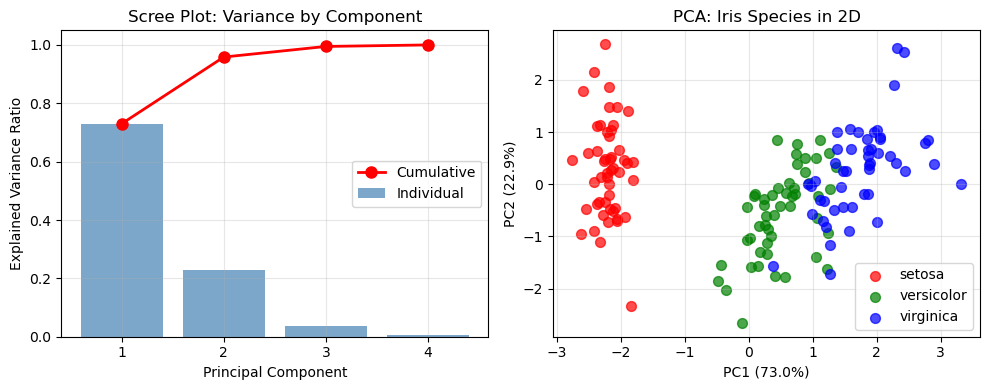


✅ What do we see?
• Setosa is clearly separated from the other two species
• Versicolor and Virginica have some overlap
• PC1 captures most of the variance (~73%)

💡 HINT for Homework: Your diabetes plot should show Outcome 0 vs 1


In [6]:
print("\n" + "=" * 60)
print("TASK 5: PRINCIPAL COMPONENT ANALYSIS (PCA)")
print("=" * 60)

# IMPORTANT: Use SCALED data for PCA!
print("✅ Using scaled features for PCA (this is critical!)")

# Step 1: PCA with all components to see variance explained
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

# Explained variance ratio
var_ratio = pca_full.explained_variance_ratio_
cumulative = np.cumsum(var_ratio)

print("\n✅ Explained Variance by each component:")
for i, (var, cum) in enumerate(zip(var_ratio, cumulative), 1):
    print(f"PC{i}: {var:.3f} ({var*100:.1f}%) - Cumulative: {cum:.3f} ({cum*100:.1f}%)")

# Scree plot (variance plot) - 5 points
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.bar(range(1, len(var_ratio)+1), var_ratio, alpha=0.7, color='steelblue')
plt.plot(range(1, len(var_ratio)+1), cumulative, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot: Variance by Component')
plt.xticks(range(1, len(var_ratio)+1))
plt.legend(['Cumulative', 'Individual'])
plt.grid(True, alpha=0.3)

# Step 2: PCA with 2 components for visualization
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# Create DataFrame for plotting
pca_df = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
pca_df['species'] = y.values

print(f"\n✅ PCA with 2 components:")
print(f"PC1 explains: {pca_2d.explained_variance_ratio_[0]:.3f} ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)")
print(f"PC2 explains: {pca_2d.explained_variance_ratio_[1]:.3f} ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)")
print(f"Total explained: {sum(pca_2d.explained_variance_ratio_):.3f} ({sum(pca_2d.explained_variance_ratio_)*100:.1f}%)")

# 2D visualization - 10 points
plt.subplot(1, 2, 2)
colors = {'setosa': 'red', 'versicolor': 'green', 'virginica': 'blue'}
for species, color in colors.items():
    mask = pca_df['species'] == species
    plt.scatter(pca_df[mask]['PC1'], pca_df[mask]['PC2'], 
                c=color, label=species, alpha=0.7, s=50)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA: Iris Species in 2D')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ What do we see?")
print("• Setosa is clearly separated from the other two species")
print("• Versicolor and Virginica have some overlap")
print("• PC1 captures most of the variance (~73%)")

print("\n💡 HINT for Homework: Your diabetes plot should show Outcome 0 vs 1")

# TASK 6: Interpretation (10 points)
## Skills: Identify important features from PCA loadings

In [7]:
print("\n" + "=" * 60)
print("TASK 6: INTERPRETATION")
print("=" * 60)

# Get feature loadings (contributions to each PC)
loadings = pd.DataFrame(
    pca_2d.components_.T,
    columns=['PC1', 'PC2'],
    index=X.columns
)

print("\n✅ Feature Loadings (how much each original feature contributes):")
print(loadings)

print("\n✅ Most important features for PC1 (sorted by absolute value):")
print(loadings['PC1'].abs().sort_values(ascending=False))

print("\n✅ Most important features for PC2 (sorted by absolute value):")
print(loadings['PC2'].abs().sort_values(ascending=False))

print("\n✅ Interpretation:")
print("• PC1 is dominated by petal_length and petal_width")
print("  → PC1 represents 'petal size' (large petals = versicolor/virginica)")
print("• PC2 is dominated by sepal_length and sepal_width")  
print("  → PC2 represents 'sepal proportions'")
print("• sepal_area (our new feature) also contributes significantly")

print("\n💡 HINT for Homework: Check which features have highest loadings for PC1 and PC2")


TASK 6: INTERPRETATION

✅ Feature Loadings (how much each original feature contributes):
                   PC1       PC2
sepal_length  0.522062  0.373341
sepal_width  -0.267692  0.924859
petal_length  0.580312  0.024311
petal_width   0.564828  0.068273

✅ Most important features for PC1 (sorted by absolute value):
petal_length    0.580312
petal_width     0.564828
sepal_length    0.522062
sepal_width     0.267692
Name: PC1, dtype: float64

✅ Most important features for PC2 (sorted by absolute value):
sepal_width     0.924859
sepal_length    0.373341
petal_width     0.068273
petal_length    0.024311
Name: PC2, dtype: float64

✅ Interpretation:
• PC1 is dominated by petal_length and petal_width
  → PC1 represents 'petal size' (large petals = versicolor/virginica)
• PC2 is dominated by sepal_length and sepal_width
  → PC2 represents 'sepal proportions'
• sepal_area (our new feature) also contributes significantly

💡 HINT for Homework: Check which features have highest loadings for PC1 an

# SUMMARY: How to Apply This to Your Diabetes Homework

In [8]:
print("\n" + "=" * 60)
print("HOW TO COMPLETE YOUR DIABETES HOMEWORK")
print("=" * 60)

print("""
Follow these exact steps with diabetes.csv:

1. LOAD DATA (5 pts)
   df = pd.read_csv('diabetes.csv')
   
2. EXPLORE (10 pts)  
   df.describe()
   df.isnull().sum()
   
3. CLEAN ZEROS (10 pts)
   cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
   for col in cols:
       df[col] = df[col].replace(0, df[col].median())
   
4. REMOVE DUPLICATES (5 pts)
   df = df.drop_duplicates()
   
5. SEPARATE X AND y
   X = df.drop('Outcome', axis=1)
   y = df['Outcome']
   
6. STANDARDIZE (20 pts)
   scaler = StandardScaler()
   X_scaled = scaler.fit_transform(X)
   
7. FEATURE ENGINEERING (15 pts)
   df['BMI_log'] = np.log(df['BMI'])  # or create your own!
   
8. PCA (25 pts)
   pca = PCA()
   pca.fit(X_scaled)
   # Print explained_variance_ratio_
   # Make scree plot
   # Make 2D scatter plot colored by Outcome
   
9. INTERPRET (10 pts)
   # Check which features have highest loadings
   # Write your conclusions

10. SUBMIT .py file with comments!
""")

print("\n" + "=" * 60)
print("LAB COMPLETE! YOU'RE READY FOR THE HOMEWORK! 🎉")
print("=" * 60)


HOW TO COMPLETE YOUR DIABETES HOMEWORK

Follow these exact steps with diabetes.csv:

1. LOAD DATA (5 pts)
   df = pd.read_csv('diabetes.csv')
   
2. EXPLORE (10 pts)  
   df.describe()
   df.isnull().sum()
   
3. CLEAN ZEROS (10 pts)
   cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
   for col in cols:
       df[col] = df[col].replace(0, df[col].median())
   
4. REMOVE DUPLICATES (5 pts)
   df = df.drop_duplicates()
   
5. SEPARATE X AND y
   X = df.drop('Outcome', axis=1)
   y = df['Outcome']
   
6. STANDARDIZE (20 pts)
   scaler = StandardScaler()
   X_scaled = scaler.fit_transform(X)
   
7. FEATURE ENGINEERING (15 pts)
   df['BMI_log'] = np.log(df['BMI'])  # or create your own!
   
8. PCA (25 pts)
   pca = PCA()
   pca.fit(X_scaled)
   # Print explained_variance_ratio_
   # Make scree plot
   # Make 2D scatter plot colored by Outcome
   
9. INTERPRET (10 pts)
   # Check which features have highest loadings
   # Write your conclusions

10. SUBMIT .py file with co